## Setup — change to repo root

In [2]:
import os
os.getcwd()
os.chdir(r"C:\Users\Melis\OneDrive\Desktop\cap\lse-bitcoin-analytics-capstone-template")

## Imports

In [3]:
import numpy as np
import pandas as pd
import logging
from pathlib import Path

logging.basicConfig(
    format="%(asctime)s %(levelname)-8s %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
)


C:\Users\Melis\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load BTC Data

In [5]:
CLASSIFICATION_CSV = r"C:\Users\Melis\OneDrive\Desktop\question_classifications.csv"

classification_df = pd.read_csv(CLASSIFICATION_CSV)
print(f"Shape: {classification_df.shape}")
print(f"Columns: {list(classification_df.columns)}")
print("BTC direction distribution:")
print(classification_df["btc_direction"].value_counts())
classification_df.head()


Shape: (36043, 4)
Columns: ['question', 'topic', 'confidence', 'btc_direction']
BTC direction distribution:
btc_direction
 1    25908
 0     9988
-1      147
Name: count, dtype: int64


,question,topic,confidence,btc_direction
0,Trump ends Ukraine war in first 90 days?,other,0.259,0
1,Will Trump pardon Hunter Biden?,other,0.531,0
2,Trump ends taxes on tips in first 100 days?,Trump policy and executive order,0.561,1
3,Trump signs national abortion ban?,Trump policy and executive order,0.621,1
4,Will Trump pardon Diddy in his first 100 days?,other,0.461,0


## Load Polymarket Classifications

> This CSV was produced by the LLM zero-shot classifier in the EDA notebook.
> Columns needed: `question`, `btc_direction` (-1/0/+1), `confidence`

In [7]:
POLYMARKET_DIR = r"C:\Users\Melis\OneDrive\Desktop\data\Polymarket"

# Only load the columns we need — trades file is very large
trades = pd.read_parquet(
    f"{POLYMARKET_DIR}/finance_politics_trades.parquet",
    columns=["market_id", "timestamp", "price"]
)
markets = pd.read_parquet(
    f"{POLYMARKET_DIR}/finance_politics_markets.parquet",
    columns=["market_id", "question"]
)

print(f"Trades shape:  {trades.shape}")
print(f"Markets shape: {markets.shape}")
print(f"Trades columns: {list(trades.columns)}")

Trades shape:  (27013724, 3)
Markets shape: (78321, 2)
Trades columns: ['market_id', 'timestamp', 'price']


## Load Polymarket Trades

> We need the trades parquet to get daily question activity.

In [9]:
POLYMARKET_DIR = r"C:\Users\Melis\OneDrive\Desktop\data\Polymarket"

import pyarrow.parquet as pq
import gc

# ── Read trades in chunks ────────────────────────────────────────────────────
print("Reading trades in chunks...")
trades_file = pq.ParquetFile(f"{POLYMARKET_DIR}/finance_politics_trades.parquet")

chunks = []
for i, batch in enumerate(trades_file.iter_batches(
    batch_size=100_000,
    columns=["market_id", "timestamp", "price"]
)):
    chunks.append(batch.to_pandas())
    if (i + 1) % 10 == 0:
        print(f"  {(i+1)*100_000:,} rows loaded...")

trades = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"Trades shape: {trades.shape}")

# ── Read markets (small file, fine to load normally) ─────────────────────────
markets = pd.read_parquet(
    f"{POLYMARKET_DIR}/finance_politics_markets.parquet",
    columns=["market_id", "question"]
)

print(f"Markets shape: {markets.shape}")
print(f"Trades columns: {list(trades.columns)}")

Reading trades in chunks...
  1,000,000 rows loaded...
  2,000,000 rows loaded...
  3,000,000 rows loaded...
  4,000,000 rows loaded...
  5,000,000 rows loaded...
  6,000,000 rows loaded...
  7,000,000 rows loaded...
  8,000,000 rows loaded...
  9,000,000 rows loaded...
  10,000,000 rows loaded...
  11,000,000 rows loaded...
  12,000,000 rows loaded...
  13,000,000 rows loaded...
  14,000,000 rows loaded...
  15,000,000 rows loaded...
  16,000,000 rows loaded...
  17,000,000 rows loaded...
  18,000,000 rows loaded...
  19,000,000 rows loaded...
  20,000,000 rows loaded...
  21,000,000 rows loaded...
  22,000,000 rows loaded...
  23,000,000 rows loaded...
  24,000,000 rows loaded...
  25,000,000 rows loaded...
  26,000,000 rows loaded...
  27,000,000 rows loaded...
Trades shape: (27013724, 3)
Markets shape: (78321, 2)
Trades columns: ['market_id', 'timestamp', 'price']


## Fix Timestamps & Build daily_odds

In [10]:
# Fix timestamp (microseconds stored incorrectly)
trades["date"] = pd.to_datetime(
    trades["timestamp"].astype("int64") // 1_000_000, unit="s"
).dt.normalize()

print(f"Date range: {trades['date'].min()} to {trades['date'].max()}")

# Merge trades with market questions
trades_with_questions = trades.merge(markets, on="market_id", how="inner")

daily_odds = (
    trades_with_questions
    .groupby(["market_id", "question", "date"])["price"]
    .mean()
    .reset_index()
    .sort_values(["market_id", "date"])
)

print(f"\ndaily_odds shape: {daily_odds.shape}")
daily_odds.head()


Date range: 2025-04-07 00:00:00 to 2026-01-05 00:00:00

daily_odds shape: (143979, 4)


,market_id,question,date,price
0,510319,Trump ends Ukraine war in first 90 days?,2025-04-07,0.032923
1,510319,Trump ends Ukraine war in first 90 days?,2025-04-08,0.027126
2,510319,Trump ends Ukraine war in first 90 days?,2025-04-09,0.025042
3,510319,Trump ends Ukraine war in first 90 days?,2025-04-10,0.022826
4,510319,Trump ends Ukraine war in first 90 days?,2025-04-11,0.023415


## Build Polymarket Contrarian Signal

**Key finding from validation (notebook Phase 2.4):**
- When classifier predicts **Bullish** → BTC returns **-0.152%** (p=0.000)
- When classifier predicts **Bearish** → BTC returns **+0.943%** (p=0.013)

The signal is **inverted** — Polymarket crowd is overcrowded on the Bullish side.
We flip the sign so: Bearish crowd = buy more, Bullish crowd = buy less.

In [11]:
# ── Step 1: Merge classifications with daily_odds ──────────────────────────
trades_classified = trades_with_questions.merge(
    classification_df[["question", "btc_direction", "confidence"]],
    on="question",
    how="inner"
)

print(f"Classified trades: {len(trades_classified):,}")
print(f"Date range: {trades_classified['date'].min()} to {trades_classified['date'].max()}")

# ── Step 2: Compute daily confidence-weighted sentiment ─────────────────────
trades_classified["weighted_dir"] = (
    trades_classified["btc_direction"] * trades_classified["confidence"]
)

daily_sentiment = (
    trades_classified.groupby("date")
    .agg(
        weighted_sum=("weighted_dir", "sum"),
        conf_sum=("confidence",        "sum"),
    )
    .assign(raw_sentiment=lambda x: x["weighted_sum"] / x["conf_sum"].clip(lower=1e-6))
    ["raw_sentiment"]
)

print(f"\nDaily sentiment computed: {len(daily_sentiment)} days")
print(f"Mean raw sentiment: {daily_sentiment.mean():.3f}  (positive = Bullish crowd)")
daily_sentiment.tail()


Classified trades: 27,013,724
Date range: 2025-04-07 00:00:00 to 2026-01-05 00:00:00

Daily sentiment computed: 257 days
Mean raw sentiment: 0.721  (positive = Bullish crowd)


date
2025-12-31    0.314277
2026-01-01    0.163540
2026-01-02    0.066063
2026-01-03    0.082814
2026-01-05    0.003796
Name: raw_sentiment, dtype: float64

In [12]:
# ── Step 3: INVERT (contrarian) ────────────────────────────────────────────
# Bullish crowd = reduce DCA = negative signal
# Bearish crowd = increase DCA = positive signal
inverted = -daily_sentiment

# ── Step 4: Smooth with 7-day rolling mean ──────────────────────────────────
SMOOTHING_DAYS = 7
smoothed = inverted.rolling(SMOOTHING_DAYS, min_periods=1).mean()

# ── Step 5: Normalise to [-1, 1] ────────────────────────────────────────────
roll_max = smoothed.abs().rolling(90, min_periods=30).quantile(0.9).clip(lower=1e-6)
polymarket_signal = (smoothed / roll_max).clip(-1, 1).fillna(0)

print(f"Signal stats:")
print(f"  mean:     {polymarket_signal.mean():.3f}")
print(f"  std:      {polymarket_signal.std():.3f}")
print(f"  min:      {polymarket_signal.min():.3f}")
print(f"  max:      {polymarket_signal.max():.3f}")
print(f"  non-zero: {(polymarket_signal != 0).sum()} days")

# Save for inspection
polymarket_signal.name = "polymarket_signal"
polymarket_signal.to_csv("polymarket_signal.csv", header=True)
print("\nSaved polymarket_signal.csv")


Signal stats:
  mean:     -0.840
  std:      0.318
  min:      -1.000
  max:      0.000
  non-zero: 228 days

Saved polymarket_signal.csv


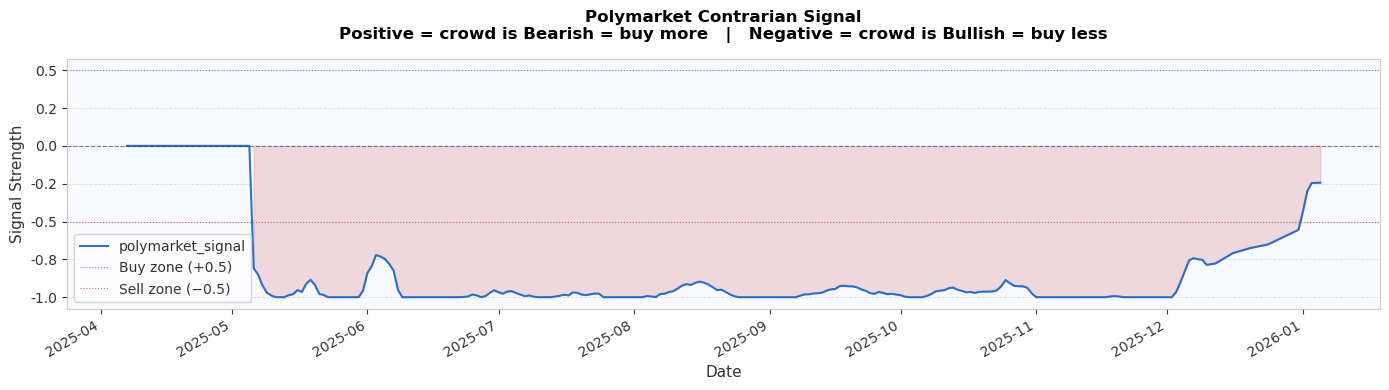

In [14]:
# ── Quick plot to inspect the signal ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8faff")

# Fill areas
ax.fill_between(polymarket_signal.index, polymarket_signal, 0,
                where=polymarket_signal >= 0, alpha=0.15, color="#1565c0", label="_nolegend_")
ax.fill_between(polymarket_signal.index, polymarket_signal, 0,
                where=polymarket_signal < 0,  alpha=0.15, color="#b71c1c", label="_nolegend_")

# Main line
polymarket_signal.plot(ax=ax, color="#1565c0", linewidth=1.5, alpha=0.9)

# Reference lines
ax.axhline(0,    color="#333333", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(0.5,  color="#1976d2", linewidth=0.8, linestyle=":",  alpha=0.7, label="Buy zone (+0.5)")
ax.axhline(-0.5, color="#c62828", linewidth=0.8, linestyle=":",  alpha=0.7, label="Sell zone (−0.5)")

# Spine styling
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")

ax.tick_params(colors="#333333", labelsize=10)
ax.set_ylabel("Signal Strength", color="#333333", fontsize=11)
ax.set_xlabel("Date", color="#333333", fontsize=11)
ax.set_title(
    "Polymarket Contrarian Signal\nPositive = crowd is Bearish = buy more   |   Negative = crowd is Bullish = buy less",
    color="black", fontweight="bold", fontsize=12, pad=14
)
ax.legend(framealpha=0.8, edgecolor="#cccccc", labelcolor="#333333", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.grid(axis="y", color="#dddddd", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.show()

## Precompute Features

Blend two signals:
- **200-day MA (40%)** — baseline trend filter from the template
- **Polymarket contrarian (60%)** — our signal

Both are lagged 1 day to prevent look-ahead bias.

In [17]:
from template.prelude_template import load_data

btc_df = load_data()
print(btc_df.shape)
btc_df.head()

2026-04-14 16:03:58 INFO     Loading CoinMetrics BTC data from local file: C:\Users\Melis\OneDrive\Desktop\cap\lse-bitcoin-analytics-capstone-template\data\Coin Metrics\coinmetrics_btc.csv
2026-04-14 16:03:58 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-14 16:03:58 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14


(6221, 32)


,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,PriceUSD_coinmetrics
time,,,,,,,,,,,,,,,,,,,,,
2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN


In [18]:
PRICE_COL        = "PriceUSD_coinmetrics"
MA_WINDOW        = 200
DYNAMIC_STRENGTH = 2.0
MA_WEIGHT        = 0.40
POLY_WEIGHT      = 0.60
MIN_W            = 1e-6

FEATS = ["price_vs_ma", "polymarket_sentiment"]


def precompute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all features for weight calculation.

    Features (all lagged 1 day to prevent look-ahead bias):
        price_vs_ma:          distance from 200-day MA, clipped [-1, 1]
        polymarket_sentiment: contrarian Polymarket signal, clipped [-1, 1]
                              positive = crowd Bearish = buy more
                              negative = crowd Bullish = buy less
    """
    price = df[PRICE_COL].loc["2010-07-18":].copy()

    # 200-day MA signal
    ma = price.rolling(MA_WINDOW, min_periods=MA_WINDOW // 2).mean()
    price_vs_ma = ((price / ma) - 1).clip(-1, 1).fillna(0)

    # Align Polymarket signal to BTC index
    poly_aligned = polymarket_signal.reindex(price.index).ffill(limit=14).fillna(0)

    features = pd.DataFrame(
        {
            PRICE_COL:              price,
            "price_ma":             ma,
            "price_vs_ma":          price_vs_ma.shift(1).fillna(0),
            "polymarket_sentiment": poly_aligned.shift(1).fillna(0),
        },
        index=price.index,
    )

    logging.info(f"Features: {len(features)} rows")
    logging.info(f"  price_vs_ma range:          [{features['price_vs_ma'].min():.3f}, {features['price_vs_ma'].max():.3f}]")
    logging.info(f"  polymarket_sentiment range:  [{features['polymarket_sentiment'].min():.3f}, {features['polymarket_sentiment'].max():.3f}]")

    return features


_FEATURES_DF = precompute_features(btc_df)
_FEATURES_DF.tail()

2026-04-14 16:03:59 INFO     Features: 5660 rows
2026-04-14 16:03:59 INFO       price_vs_ma range:          [-0.768, 1.000]
2026-04-14 16:03:59 INFO       polymarket_sentiment range:  [-1.000, 0.000]


,PriceUSD_coinmetrics,price_ma,price_vs_ma,polymarket_sentiment
time,,,,
2026-01-10,90406.142411,106347.539014,-0.149266,-0.243527
2026-01-11,90717.206315,106264.599720,-0.149899,-0.243527
2026-01-12,91141.149849,106185.241355,-0.146308,-0.243527
2026-01-13,95304.498294,106126.309051,-0.141678,-0.243527
2026-01-14,NaN,106120.121573,-0.101971,-0.243527


## Dynamic Multiplier — Blended Signal

In [19]:
def compute_dynamic_multiplier(
    price_vs_ma: np.ndarray,
    polymarket_sentiment: np.ndarray,
) -> np.ndarray:
    """Blend MA and Polymarket signals into a weight multiplier.

    MA signal (40%):
        below MA → positive signal → buy more
    Polymarket contrarian (60%):
        crowd Bearish → positive signal → buy more (contrarian)
        crowd Bullish → negative signal → buy less (contrarian)
    """
    ma_signal   = -price_vs_ma        # negative price_vs_ma = below MA = buy more
    poly_signal = polymarket_sentiment # already inverted in precompute_features

    blended    = (MA_WEIGHT * ma_signal) + (POLY_WEIGHT * poly_signal)
    adjustment = np.clip(blended * DYNAMIC_STRENGTH, -3, 3)
    multiplier = np.exp(adjustment)

    return np.where(np.isfinite(multiplier), multiplier, 1.0)


# Quick sanity check
test_ma   = np.array([-0.5, 0.0, 0.5])
test_poly = np.array([ 0.5, 0.0, -0.5])
mults     = compute_dynamic_multiplier(test_ma, test_poly)
print("Sanity check (should be > 1 for first, ~1 for middle, < 1 for last):")
for ma, poly, m in zip(test_ma, test_poly, mults):
    print(f"  MA={ma:+.1f}  Poly={poly:+.1f}  →  multiplier={m:.3f}")


Sanity check (should be > 1 for first, ~1 for middle, < 1 for last):
  MA=-0.5  Poly=+0.5  →  multiplier=2.718
  MA=+0.0  Poly=+0.0  →  multiplier=1.000
  MA=+0.5  Poly=-0.5  →  multiplier=0.368


## Weight Allocation Functions

> Same as the template — do not modify these.

In [20]:
def _compute_stable_signal(raw: np.ndarray) -> np.ndarray:
    n = len(raw)
    if n == 0: return np.array([])
    if n == 1: return np.array([1.0])
    cumsum       = np.cumsum(raw)
    running_mean = cumsum / np.arange(1, n + 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        signal = raw / running_mean
    return np.where(np.isfinite(signal), signal, 1.0)


def allocate_sequential_stable(
    raw: np.ndarray,
    n_past: int,
    locked_weights: np.ndarray | None = None,
) -> np.ndarray:
    n = len(raw)
    if n == 0: return np.array([])
    if n_past <= 0: return np.full(n, 1.0 / n)
    n_past = min(n_past, n)
    w = np.zeros(n)
    base_weight = 1.0 / n

    if locked_weights is not None and len(locked_weights) >= n_past:
        w[:n_past] = locked_weights[:n_past]
    else:
        for i in range(n_past):
            signal = _compute_stable_signal(raw[: i + 1])[-1]
            w[i]   = signal * base_weight

    past_sum = w[:n_past].sum()
    target   = n_past / n
    if past_sum > target + 1e-10:
        w[:n_past] *= target / past_sum

    n_future = n - n_past
    if n_future > 1:
        w[n_past : n - 1] = base_weight

    w[n - 1] = max(1.0 - w[: n - 1].sum(), 0)
    return w


def _clean_array(arr: np.ndarray) -> np.ndarray:
    return np.where(np.isfinite(arr), arr, 0)


def compute_weights_fast(
    features_df: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    n_past: int | None = None,
    locked_weights: np.ndarray | None = None,
) -> pd.Series:
    df   = features_df.loc[start_date:end_date]
    if df.empty: return pd.Series(dtype=float)
    n    = len(df)
    base = np.ones(n) / n

    price_vs_ma          = _clean_array(df["price_vs_ma"].values)
    polymarket_sentiment = _clean_array(df["polymarket_sentiment"].values)

    dyn    = compute_dynamic_multiplier(price_vs_ma, polymarket_sentiment)
    raw    = base * dyn
    if n_past is None: n_past = n
    weights = allocate_sequential_stable(raw, n_past, locked_weights)
    return pd.Series(weights, index=df.index)


def compute_window_weights(
    features_df: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    current_date: pd.Timestamp,
    locked_weights: np.ndarray | None = None,
) -> pd.Series:
    full_range = pd.date_range(start=start_date, end=end_date, freq="D")
    missing    = full_range.difference(features_df.index)
    if len(missing) > 0:
        placeholder = pd.DataFrame({col: 0.0 for col in features_df.columns}, index=missing)
        features_df = pd.concat([features_df, placeholder]).sort_index()

    past_end = min(current_date, end_date)
    n_past   = len(pd.date_range(start=start_date, end=past_end, freq="D")) if start_date <= past_end else 0

    weights = compute_weights_fast(features_df, start_date, end_date, n_past, locked_weights)
    return weights.reindex(full_range, fill_value=0.0)


print("Weight functions defined.")


Weight functions defined.


## Backtest Wrapper

> Same interface as `compute_weights_modal` in the template.

In [21]:
from template.prelude_template import (
    backtest_dynamic_dca,
    check_strategy_submission_ready,
    parse_window_dates,
)
from template.backtest_template import run_full_analysis


def compute_weights_modal(df_window: pd.DataFrame) -> pd.Series:
    """Interface expected by the backtest engine.

    Takes a DataFrame window slice, returns weights summing to 1.0.
    Uses global _FEATURES_DF (precomputed above).
    """
    if df_window.empty:
        return pd.Series(dtype=float)

    start_date   = df_window.index.min()
    end_date     = df_window.index.max()
    current_date = end_date  # all dates are past in backtest mode

    return compute_window_weights(_FEATURES_DF, start_date, end_date, current_date)


print("compute_weights_modal defined.")


compute_weights_modal defined.


## Run Full Backtest

2026-04-14 16:10:03 INFO     Running SPD backtest for 'Polymarket Sentiment DCA (Melissa)'...
2026-04-14 16:10:03 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-04-14 16:10:57 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-14 16:10:57 INFO     Aggregated Metrics for Polymarket Sentiment DCA (Melissa):
2026-04-14 16:10:57 INFO       SPD: min=1010.24, max=19850.48, mean=6643.30, median=4016.41
2026-04-14 16:10:57 INFO       Percentile: min=18.78%, max=68.41%, mean=39.29%, median=39.02%
2026-04-14 16:10:57 INFO       Exp-decay avg SPD percentile: 51.76%
2026-04-14 16:10:57 INFO     Running strategy validation...


Validating strategy submission readiness...


2026-04-14 16:12:07 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-04-14 16:12:40 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)



⚠️ Windows where strategy underperformed Uniform DCA:


,dynamic_percentile,uniform_percentile,Delta
window,,,
2018-06-22 → 2019-06-22,45.690851,45.723495,-0.032644
2018-06-23 → 2019-06-23,45.816099,45.866166,-0.050067
2018-06-24 → 2019-06-24,46.138960,46.207643,-0.068683
2018-06-25 → 2019-06-25,47.201443,47.431388,-0.229944
2018-06-26 → 2019-06-26,48.567474,49.013770,-0.446296
...,...,...,...
2024-10-07 → 2025-10-07,26.235230,27.857298,-1.622068
2024-10-08 → 2025-10-08,25.673565,27.605603,-1.932038
2024-10-09 → 2025-10-09,25.803387,27.355314,-1.551927


2026-04-14 16:12:40 INFO     Final Model Score: 55.10%
2026-04-14 16:12:40 INFO       Excess percentile: mean=0.59%, median=0.38%
2026-04-14 16:12:40 INFO       Relative improvement: mean=1.50%, median=0.98%
2026-04-14 16:12:40 INFO       Ratio (dynamic/uniform): mean=1.02, median=1.01
2026-04-14 16:12:40 INFO     Generating visualizations...



Summary: 1063/2557 underperformed (58.43% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

✅ Strategy is ready for submission.


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
2026-04-14 16:12:42 INFO     ✓ Saved: output\polymarket_sentiment\performance_comparison.svg
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
2026-04-14 16:12:43 INFO     ✓ Saved: output\polymarket_sentiment\excess_percentile_distribution.svg


AttributeError: Rectangle.set() got an unexpected keyword argument 'legend'

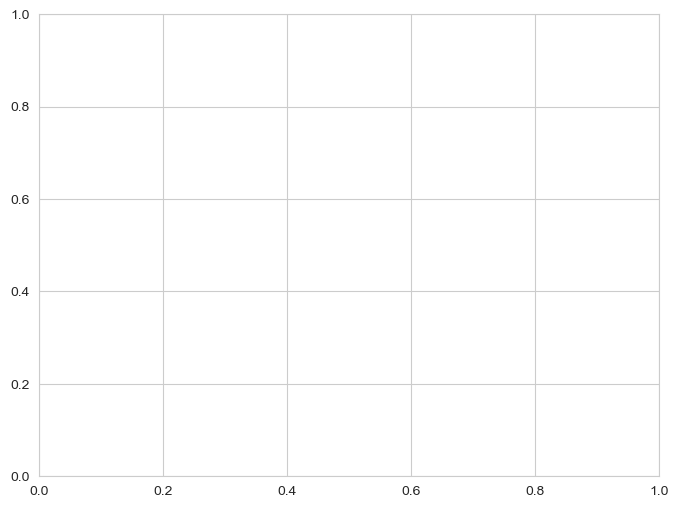

In [23]:
output_dir = Path("output/polymarket_sentiment")

run_full_analysis(
    btc_df             = btc_df,
    features_df        = _FEATURES_DF,
    compute_weights_fn = compute_weights_modal,
    output_dir         = output_dir,
    strategy_label     = "Polymarket Sentiment DCA (Melissa)",
)

## Validate

In [24]:
check_strategy_submission_ready(btc_df, compute_weights_modal)


Validating strategy submission readiness...


2026-04-14 16:13:49 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-04-14 16:14:22 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)



⚠️ Windows where strategy underperformed Uniform DCA:


,dynamic_percentile,uniform_percentile,Delta
window,,,
2018-06-22 → 2019-06-22,45.690851,45.723495,-0.032644
2018-06-23 → 2019-06-23,45.816099,45.866166,-0.050067
2018-06-24 → 2019-06-24,46.138960,46.207643,-0.068683
2018-06-25 → 2019-06-25,47.201443,47.431388,-0.229944
2018-06-26 → 2019-06-26,48.567474,49.013770,-0.446296
...,...,...,...
2024-10-07 → 2025-10-07,26.235230,27.857298,-1.622068
2024-10-08 → 2025-10-08,25.673565,27.605603,-1.932038
2024-10-09 → 2025-10-09,25.803387,27.355314,-1.551927



Summary: 1063/2557 underperformed (58.43% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

✅ Strategy is ready for submission.
